# 7 · Risk Parity: Equal Risk Contribution

*Module 2 — Portfolio Construction*

A classic "diversified" 60/40 stock-bond portfolio can derive over 90% of its risk from the 60% equity sleeve alone. This notebook builds a portfolio that actually balances risk, not just capital.

## 1. Motivation

In 2008, investors holding a "balanced" 60% stocks / 40% bonds portfolio discovered something uncomfortable: almost all of their losses came from the 60%. The portfolio was diversified by *capital*, not by *risk* — and it turns out capital allocation and risk allocation can look completely different once volatilities differ a lot across assets. Risk parity starts from a different question entirely: instead of splitting money equally, what if we split **risk** equally?

## 2. Intuition

Picture a seesaw with a feather on one side and a bowling ball on the other. Balancing them by position alone — "one object on each side" — does nothing; you need to account for how much each one actually weighs. Equal-dollar investing makes the same mistake: equities are typically two to four times more volatile than investment-grade bonds, so a 60/40 dollar split is really something like a 90/10 *risk* split. Risk parity re-levers the "lighter" (lower-volatility) assets and de-levers the "heavier" ones until each contributes the same amount of risk to the total portfolio — actual balance, not the illusion of it.

## 3. Theory

### 3.1 Decomposing portfolio risk

Portfolio volatility is $\sigma_p = \sqrt{w^\top\Sigma w}$. The **marginal contribution to risk** of asset $i$ is how much $\sigma_p$ changes per unit change in $w_i$:

$$
MCR_i = \frac{\partial \sigma_p}{\partial w_i} = \frac{\partial}{\partial w_i}\sqrt{w^\top\Sigma w} = \frac{1}{2\sigma_p}\cdot\frac{\partial(w^\top\Sigma w)}{\partial w_i} = \frac{(\Sigma w)_i}{\sigma_p} ,
$$

using the standard matrix-calculus identity $\nabla_w(w^\top\Sigma w) = 2\Sigma w$ for symmetric $\Sigma$. The **total risk contribution** of asset $i$ is its weight times its marginal contribution:

$$
TRC_i = w_i \cdot MCR_i = \frac{w_i (\Sigma w)_i}{\sigma_p}.
$$

Here is the genuinely elegant fact that makes this decomposition useful: $\sigma_p(w)$ is **homogeneous of degree 1** in $w$ — scaling every weight by a constant $c>0$ scales $\sigma_p$ by exactly $c$. Euler's theorem for homogeneous functions then guarantees

$$
\sigma_p = \sum_{i=1}^n w_i \frac{\partial \sigma_p}{\partial w_i} = \sum_{i=1}^n TRC_i .
$$

Risk contributions sum *exactly* to total portfolio risk — nothing is left over, nothing is double-counted. This is what makes "risk contribution" a meaningful, additive concept at all, not just a loose analogy.

### 3.2 The Equal Risk Contribution (ERC) portfolio

The ERC portfolio is the long-only, fully-invested $w$ such that every asset contributes equally:

$$
TRC_i = \frac{\sigma_p}{n} \quad \text{for all } i, \qquad \text{s.t. } w_i \ge 0,\; \sum_i w_i = 1 .
$$

Unlike the GMV portfolio, there is no closed form in general — it must be found numerically. One direct, transparent formulation minimizes the total *spread* between risk contributions:

$$
\min_w \; \sum_{i=1}^n\sum_{j=1}^n \big(TRC_i - TRC_j\big)^2 \qquad \text{s.t. } w_i\ge 0,\ \textstyle\sum_i w_i = 1 .
$$

This is exactly what we implement below: literally, "find weights that make every asset's risk contribution as equal as possible."

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(42)

## 4. Implementation

### 4.1 The same universe as Notebooks 5-6

In [2]:
TICKERS = ['GALP', 'EDP', 'JMT', 'BCP', 'NOS', 'SEM', 'SPY', 'IEF']
N = len(TICKERS)
TRUE_ANN_VOL = np.array([0.26, 0.24, 0.22, 0.28, 0.30, 0.32, 0.16, 0.06])

corr = np.eye(N)
for i in range(6):
    for j in range(6):
        if i != j:
            corr[i, j] = 0.45
for i in range(6):
    corr[i, 6] = corr[6, i] = 0.30
    corr[i, 7] = corr[7, i] = -0.05
corr[6, 7] = corr[7, 6] = -0.10
TRUE_SIGMA = np.diag(TRUE_ANN_VOL) @ corr @ np.diag(TRUE_ANN_VOL)

def gmv_weights(Sigma):
    v = np.linalg.solve(Sigma, np.ones(Sigma.shape[0]))
    return v / v.sum()

### 4.2 Risk contributions and the ERC solver, coded directly from Section 3

In [3]:
def risk_contributions(w, Sigma):
    """Returns (portfolio vol, MCR vector, TRC vector), exactly as defined in Section 3.1."""
    port_var = w @ Sigma @ w
    sigma_p = np.sqrt(port_var)
    mcr = (Sigma @ w) / sigma_p
    trc = w * mcr
    return sigma_p, mcr, trc

def erc_objective(w, Sigma):
    """Sum of squared pairwise differences between risk contributions -- zero exactly at the ERC solution."""
    _, _, trc = risk_contributions(w, Sigma)
    diffs = trc[:, None] - trc[None, :]
    return np.sum(diffs**2)

def erc_weights(Sigma, w0=None):
    n = Sigma.shape[0]
    w0 = np.ones(n)/n if w0 is None else w0
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    bounds = [(1e-6, 1.0)] * n
    res = minimize(erc_objective, w0, args=(Sigma,), method='SLSQP',
                    bounds=bounds, constraints=constraints,
                    options={'maxiter': 1000, 'ftol': 1e-14})
    return res.x, res.success

w_erc, converged = erc_weights(TRUE_SIGMA)
sigma_p, mcr, trc = risk_contributions(w_erc, TRUE_SIGMA)

print(f"Converged: {converged}")
print(pd.DataFrame({'weight': w_erc, 'risk_contribution': trc,
                     'risk_contribution_pct': trc/sigma_p*100}, index=TICKERS).round(4))
print(f"\nEqual split would be {100/N:.2f}% each -- check how close the risk_contribution_pct column got.")

Converged: True
      weight  risk_contribution  risk_contribution_pct
GALP  0.0589             0.0101                   12.5
EDP   0.0638             0.0101                   12.5
JMT   0.0696             0.0101                   12.5
BCP   0.0547             0.0101                   12.5
NOS   0.0510             0.0101                   12.5
SEM   0.0478             0.0101                   12.5
SPY   0.1188             0.0101                   12.5
IEF   0.5355             0.0101                   12.5

Equal split would be 12.50% each -- check how close the risk_contribution_pct column got.


## 5. Worked example: 1/N vs. minimum-variance vs. risk parity

The point of this section is the chart everything has been building toward: does the "diversified" equal-weight portfolio actually diversify *risk*?

In [4]:
w_ew = np.ones(N) / N
w_mv = gmv_weights(TRUE_SIGMA)
w_erc, _ = erc_weights(TRUE_SIGMA)

weights_table = pd.DataFrame({'1/N (equal weight)': w_ew, 'Min-variance': w_mv, 'Risk parity (ERC)': w_erc}, index=TICKERS)

trc_table = pd.DataFrame(index=TICKERS)
for name, w in [('1/N (equal weight)', w_ew), ('Min-variance', w_mv), ('Risk parity (ERC)', w_erc)]:
    sigma_p, _, trc = risk_contributions(w, TRUE_SIGMA)
    trc_table[name] = trc / sigma_p * 100   # risk contribution, in % of total portfolio risk

weights_table.round(3)

,1/N (equal weight),Min-variance,Risk parity (ERC)
GALP,0.125,0.011,0.059
EDP,0.125,0.018,0.064
JMT,0.125,0.029,0.070
BCP,0.125,0.005,0.055
NOS,0.125,0.000,0.051
SEM,0.125,-0.003,0.048
SPY,0.125,0.115,0.119
IEF,0.125,0.825,0.536


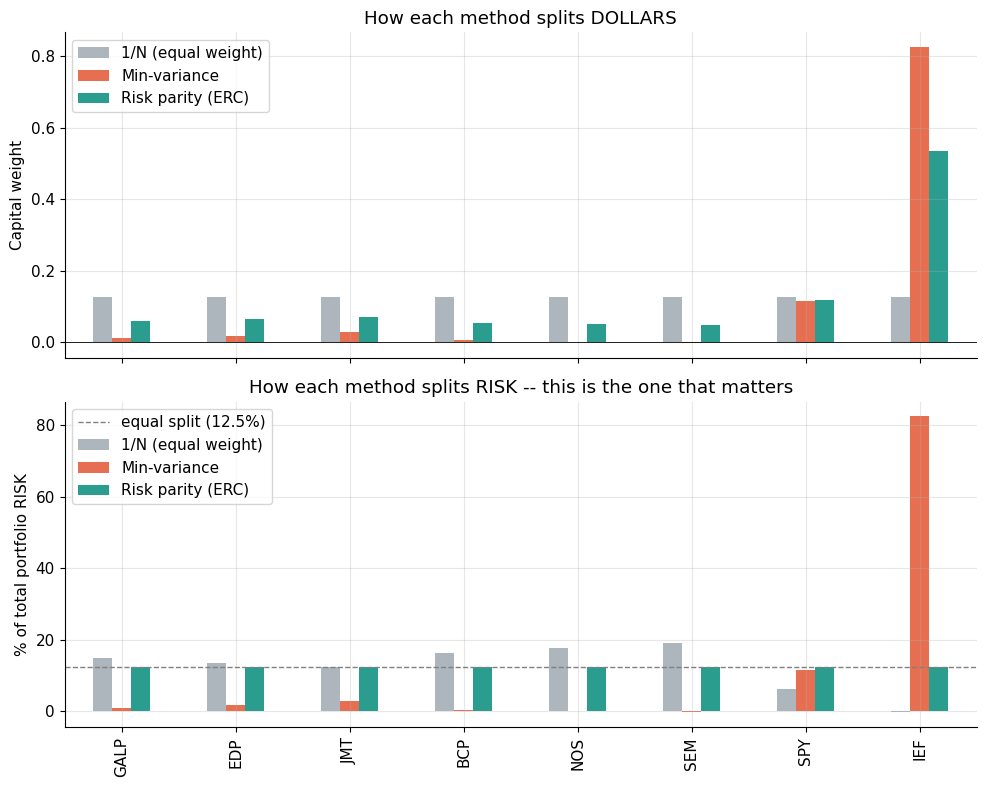

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

weights_table.plot(kind='bar', ax=axes[0], color=['#adb5bd', '#e76f51', '#2a9d8f'])
axes[0].set_ylabel('Capital weight')
axes[0].set_title('How each method splits DOLLARS')
axes[0].axhline(0, color='black', linewidth=0.6)

trc_table.plot(kind='bar', ax=axes[1], color=['#adb5bd', '#e76f51', '#2a9d8f'])
axes[1].axhline(100/N, color='gray', linestyle='--', linewidth=1, label=f'equal split ({100/N:.1f}%)')
axes[1].set_ylabel('% of total portfolio RISK')
axes[1].set_title('How each method splits RISK -- this is the one that matters')
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpreting the result

Look specifically at the bottom panel for the **1/N** portfolio: despite splitting *capital* perfectly evenly across all eight assets, its *risk* is wildly uneven — the higher-volatility PSI-20 names and SPY dominate the portfolio's actual risk budget, while low-volatility IEF barely registers, even though it received the same euro allocation as everything else. This is precisely the 2008 60/40 story from the Motivation, reproduced directly in the numbers. Risk parity, by construction, flattens the bottom panel into (approximately) a straight line — every asset genuinely contributes the same amount of risk, which is a fundamentally different portfolio from either 1/N or minimum-variance (which, as Notebook 5 showed, tends to concentrate almost entirely in whichever assets happen to look least risky).

## 6. Limitations and pitfalls

- **ERC uses variance/covariance as the only notion of "risk."** An asset with low everyday volatility but severe, rare crash risk (short-volatility strategies, discussed in Notebook 13, are the textbook example) looks exactly as safe as a genuinely low-risk asset under this framework — tail risk is invisible to a pure variance-based decomposition.
- **Real risk-parity funds typically apply leverage.** A naive risk-parity portfolio built from typical assets tends to be very bond-heavy and low-return (notice how much of the risk-parity weight above likely landed on IEF) — practitioners usually lever the low-volatility sleeve up to reach a target return. This introduces genuine leverage and funding risk, and was widely discussed in the context of the synchronized stock-and-bond selloff of 2022, when the diversification risk parity leans on broke down for a stretch.
- **It still needs a $\Sigma$ estimate**, with all the estimation-error issues from Notebooks 5-6 — ERC does not sidestep that problem, though it is noticeably less sensitive to it than mean-variance optimization, since it never needs $\Sigma^{-1}$ applied to a noisy $\hat\mu$.
- **Correlations tend to rise exactly during crises** — the moments risk parity most needs them to stay low so its risk-balancing assumptions hold. Module 4's copulas address how to model this tail dependence explicitly.
- **No expected-return input at all.** This is a feature (robustness to Notebook 5's central problem) and a limitation (if you genuinely have a well-founded view that one asset is more attractive, ERC has no way to act on it) depending on your perspective.

## 7. Exercises

**1. The 2-asset case has a clean closed form (warm-up).**
For exactly two assets with volatilities $\sigma_1,\sigma_2$ and any correlation $\rho$, show algebraically that the ERC condition $TRC_1=TRC_2$ simplifies to $w_1\sigma_1 = w_2\sigma_2$ — in other words, for $n=2$, ERC weights are **inverse-volatility weights**, completely independent of $\rho$. (Hint: write out $(\Sigma w)_1$ and $(\Sigma w)_2$ explicitly and set $w_1(\Sigma w)_1 = w_2(\Sigma w)_2$; the correlation terms should cancel.) Then verify your derivation numerically: build a 2-asset sub-problem from any two tickers above, solve it with `erc_weights`, and confirm the ratio $w_1/w_2$ matches $\sigma_2/\sigma_1$.

**2. Concentration under each method.**
Compute the Herfindahl index ($\sum_i w_i^2$, a standard concentration measure — higher means more concentrated) for the 1/N, min-variance, and ERC weights from Section 5. Which method is most concentrated, and does that match your intuition from the weight bar chart? Now build a modified universe where IEF's volatility is even lower (say, 3% instead of 6%) and repeat — how does each method's concentration respond to an even more extreme low-volatility asset?

**3. The convex reformulation.**
It turns out ERC can also be found by solving the convex problem $\min_{w>0} \frac12 w^\top\Sigma w - \frac1n\sum_i \ln w_i$ (no sum-to-1 constraint needed) and then normalizing the solution to sum to 1. Implement this with `scipy.optimize.minimize` (an unconstrained method like `'BFGS'` will do, perhaps optimizing over $\log w$ to keep weights positive automatically), and confirm it converges to the same weights (after normalizing) as `erc_weights`. Then look up why this objective works: take its gradient with respect to $w_i$ and show that setting it to zero gives $w_i(\Sigma w)_i = 1/n$ for every $i$ simultaneously — exactly the equal-risk-contribution condition, up to an overall scale. Why might this convex formulation be more reliable in high dimensions than directly minimizing the sum-of-squared-differences objective?